# COGS 108 - EDA Checkpoint

## Authors

- Andrew Zhang: Find data and describe dataset 2
- Andy Cao: Data wrangling for Dataset 1, Writing – original draft
- Vicky Huang: Find data and describe dataset 1
- Jasmine Lou: Data wrangling for Dataset 2, Writing – original draft
- Yiwen Huang: Update info, Writing – review and editing

# Research Question

How have housing prices and affordability changed over time in regions surrounding University of California (UC) campuses, and how do these trends relate to local income levels and broader economic conditions?

Specifically, we examine whether housing prices near UC campuses have increased faster than median household income and how these trends differ across regions (e.g., Irvine, La Jolla, Berkeley, Los Angeles) and time periods. The main metrics are median home price (or home value index), median household income, and affordability (e.g., price-to-income ratio or rent burden). The analysis is primarily descriptive and comparative. We will visualize price and income trends, compare regions, and assess changes in affordability over at least 10 to 20 years using public data from government and real-estate sources (e.g., Zillow, U.S. Census/ACS, FRED).


## Background and Prior Work

Housing affordability has become a major economic and social issue in California, particularly in regions with high demand and limited housing supply. Areas surrounding University of California campuses often experience additional housing pressure due to student populations, faculty demand, and local economic growth. Prior research has shown that housing prices in California have increased significantly over the past two decades, frequently outpacing wage growth and contributing to affordability challenges for renters and homeowners alike.

Several public data sources provide context. Zillow's housing market reports document long-term growth in home values across major U.S. metropolitan areas, with especially rapid increases in coastal California cities. U.S. Census data and American Community Survey (ACS) reports provide evidence that median household income growth has been slower and uneven across regions. Our project focuses on UC-adjacent regions (e.g., Irvine, La Jolla, Berkeley, Los Angeles) and compares affordability trends across multiple campuses using Zillow, Census/ACS, and FRED data.

# Hypothesis


We hypothesize that housing prices in regions surrounding UC campuses have increased faster than median household income over time, leading to decreased affordability. We also expect that UC regions in major metropolitan or coastal areas (e.g., near UC Berkeley or UCLA) will exhibit higher prices and lower affordability compared to UC campuses in less dense regions (e.g., UC Riverside or UC Merced). This is based on prior evidence that coastal and urban California markets have seen stronger price growth and that university towns often face extra demand from students and staff, while income growth has been slower and uneven across the state.

## Data

### Data overview

**Dataset 1: Zillow Home Value Index (ZHVI), Single-Family Residences**
- **Dataset name:** Zip_Zhvi_SingleFamilyResidence (ZIP code level, single-family home values).
- **Source / link:** Zillow Research Data (public mirror used in this project: `Zip_Zhvi_SingleFamilyResidence_2018.csv`).
- **Observations:** One row per ZIP code. Thousands of ZIPs nationally; we filter to California and further to UC-adjacent areas.
- **Variables:** `RegionID`, `RegionName` (ZIP), `State`, `Metro`, `CountyName`, and many date columns (e.g., 1996-04 to 2018-12) with typical home value in dollars for that month.
- **Relevance:** Provides housing price levels and growth over time at fine geography (ZIP). We can aggregate to county or metro and align with UC campus regions (e.g., Irvine, La Jolla, Berkeley, Los Angeles).
- **Limitations:** Mirror ends in 2018; geography is ZIP, so we must map ZIPs to counties/metros; single-family only.

**Dataset 2: California County Income Limits / Area Median Income (AMI)**
- **Dataset name:** 2022-income-limits (county-level Area Median Income for California).
- **Source / link:** CA Open Data portal (2022 income limits file).
- **Observations:** One row per county.
- **Key variables:** `County` (county name) and `AMI` (used as a proxy for median household income). We create a cleaned dataset with variables `county`, `year`, and `median_household_income`.
- **Relevance:** Provides an income measure at the county level that can be merged with housing prices to study affordability.
- **Limitations:** Single year (2022) in this file; ACS-based income estimates have sampling error and do not capture cost-of-living differences within the state.

**How we use them together.** We filter Zillow data to California, aggregate ZIP-level home values to the county level, and then merge with county-level income (AMI) on county names. This merged dataset supports analyses of both cross-sectional patterns (e.g., affordability differences across UC-adjacent counties) and relationships between income and home values.

In [13]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  2.47it/s]

Successfully downloaded: airline-safety.csv


Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  2.81it/s]

Successfully downloaded: bad-drivers.csv


### Dataset #1 — Zillow Home Value Index (ZHVI), Single-Family by ZIP

We use the Zillow Home Value Index (ZHVI) dataset for single-family residences at the ZIP code level. Each row corresponds to a ZIP code and contains typical home values (in USD) across many months and years. From the raw file `data/00-raw/Zip_Zhvi_SingleFamilyResidence_2018.csv`, we:

- Filter to California ZIP codes (`State == 'CA'`).
- Keep key geography columns (`RegionID`, `RegionName`, `State`, `CountyName`, `Metro`) and all date columns.
- Drop rows where all date columns are missing or zero.

The cleaned California subset is saved as `data/02-processed/zhvi_sfr_zip_ca_2018.csv`. This file provides consistent, non-missing home value time series for California ZIP codes and is the main housing-price input to our EDA.

In [15]:
import pandas as pd

zhvi_ca = pd.read_csv("data/02-processed/zhvi_sfr_zip_ca_2018.csv")

print("ZHVI (CA ZIPs) shape:", zhvi_ca.shape)
print("Columns (first 8):", list(zhvi_ca.columns[:8]))

key_cols = ["RegionID", "RegionName", "State", "CountyName", "Metro"]
date_cols = [c for c in zhvi_ca.columns if c not in key_cols]
print("Number of monthly value columns:", len(date_cols))

last_col = date_cols[-1]
print(f"\nSummary of {last_col} (typical home value, USD):")
print(zhvi_ca[last_col].describe())

ZHVI (CA ZIPs) shape: (1229, 280)
Columns (first 8): ['RegionID', 'RegionName', 'City', 'State', 'Metro', 'CountyName', 'SizeRank', '1996-04']
Number of monthly value columns: 275

Summary of 2018-12 (typical home value, USD):
count    1.229000e+03
mean     7.485329e+05
std      6.628661e+05
min      1.171000e+05
25%      3.533000e+05
50%      5.685000e+05
75%      8.854000e+05
max      6.671700e+06
Name: 2018-12, dtype: float64


### Dataset #2 — California County Income Limits / Area Median Income (AMI)

The second dataset comes from the California Department of Housing and Community Development (HCD) and provides county-level Area Median Income (AMI) for 2022. Each row corresponds to a California county and includes AMI and related income limit fields.

From the raw file `data/00-raw/2022-income-limits.csv`, we construct a cleaned dataset by:

- Renaming `County` to `county` and `AMI` to `median_household_income`.
- Adding a `year` column (2022) so the data can be aligned with other time-stamped sources.
- Keeping only the columns `county`, `year`, and `median_household_income` and coercing income values to numeric.

The cleaned income dataset is saved as `data/02-processed/income_limits_ca_2022.csv` and is used as our county-level income measure when merging with housing prices.

In [16]:
import pandas as pd

income = pd.read_csv("data/02-processed/income_limits_ca_2022.csv")

print("Income dataset shape:", income.shape)
print("Columns:", list(income.columns))
print("\nPreview:")
print(income.head())

print("\nSummary of median_household_income (USD):")
print(income["median_household_income"].describe())

Income dataset shape: (58, 3)
Columns: ['county', 'year', 'median_household_income']

Preview:
      county  year  median_household_income
0    Alameda  2022                   142800
1     Alpine  2022                    94900
2     Amador  2022                    86600
3      Butte  2022                    85000
4  Calaveras  2022                    90000

Summary of median_household_income (USD):
count        58.000000
mean      97486.206897
std       24447.576913
min       80300.000000
25%       80300.000000
50%       87000.000000
75%      106225.000000
max      168500.000000
Name: median_household_income, dtype: float64


## Results

### Exploratory Data Analysis

In this section, we explore how housing prices and affordability vary across California counties, with a focus on regions surrounding UC campuses. We load the fully wrangled datasets from `data/02-processed`:

- `zhvi_sfr_zip_ca_2018.csv`: cleaned Zillow Home Value Index (single-family) for California ZIP codes.
- `income_limits_ca_2022.csv`: cleaned county-level income limits / Area Median Income (AMI) used as a proxy for median household income.

Our EDA has two main goals:

1. Summarize the distribution of home values and income across UC-adjacent counties and compute simple affordability metrics (e.g., price-to-income ratios).
2. Examine the relationship between county-level income and home values, including visualization and correlation, to see how strongly income is associated with housing prices.

We interleave code, figures, and written interpretation. Reusable processing steps (e.g., loading processed data, aggregating ZIP values to the county level) draw on the modules and data-wrangling work from previous checkpoints rather than re-downloading raw files.

#### Section 1 — Affordability Across UC-Adjacent Counties

In this section we construct a simple cross-sectional view of housing affordability in counties that contain or border major UC campuses (for example, Alameda, Los Angeles, Orange, San Diego, Santa Barbara, Riverside, Merced, and Yolo). Using the cleaned ZHVI dataset, we summarize the most recent available home values at the ZIP level and aggregate them to the county level. We then merge these county-level home values with the 2022 income limits dataset to obtain an income measure for the same counties.

From the merged data, we compute and visualize a price-to-income ratio (typical home value divided by median household income) for each UC-adjacent county. This provides a first look at how affordability compares across regions: higher ratios indicate that home values are high relative to local incomes. We discuss which UC regions appear most and least affordable and how these findings relate to our research question about housing pressure near UC campuses.

Merged UC-adjacent counties (home value and income):
          county    home_value  year  median_household_income  price_to_income
1    Los Angeles  9.305209e+05  2022                    91100        10.214280
6  Santa Barbara  9.387944e+05  2022                   100100         9.378566
3         Orange  9.758482e+05  2022                   119100         8.193520
5      San Diego  7.785379e+05  2022                   106900         7.282862
0        Alameda  1.014916e+06  2022                   142800         7.107257
4      Riverside  4.051557e+05  2022                    87400         4.635649
7           Yolo  4.604250e+05  2022                   106600         4.319184
2         Merced  2.607900e+05  2022                    80300         3.247696


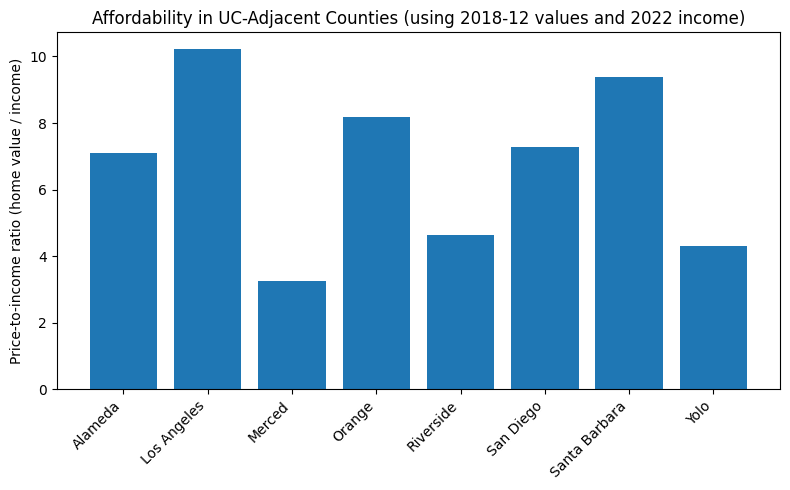

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

zhvi_ca = pd.read_csv("data/02-processed/zhvi_sfr_zip_ca_2018.csv")
income = pd.read_csv("data/02-processed/income_limits_ca_2022.csv")

zhvi_ca["county"] = zhvi_ca["CountyName"].str.replace(" County", "", regex=False)

uc_counties = [
    "Alameda",
    "Los Angeles",
    "Orange",
    "San Diego",
    "Santa Barbara",
    "Riverside",
    "Merced",
    "Yolo"
]

key_cols = ["RegionID", "RegionName", "State", "CountyName", "Metro", "county"]
date_cols = [c for c in zhvi_ca.columns if c not in key_cols]
last_col = date_cols[-1]

zhvi_uc = (
    zhvi_ca[zhvi_ca["county"].isin(uc_counties)]
    .loc[:, ["county", last_col]]
    .rename(columns={last_col: "home_value"})
)

county_values = (
    zhvi_uc
    .groupby("county", as_index=False)["home_value"].mean()
)

merged = county_values.merge(income, on="county", how="left")

merged["price_to_income"] = merged["home_value"] / merged["median_household_income"]

print("Merged UC-adjacent counties (home value and income):")
print(merged.sort_values("price_to_income", ascending=False))

plt.figure(figsize=(8, 5))
plt.bar(merged["county"], merged["price_to_income"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Price-to-income ratio (home value / income)")
plt.title(f"Affordability in UC-Adjacent Counties (using {last_col} values and 2022 income)")
plt.tight_layout()
plt.show()

#### Section 2 County-Level Relationship Between Area Median Income (AMI) and Home Values

In this section, we construct a county-level dataset by combining Area Median Income (AMI) with Zillow home values for California. Since Zillow data are reported at the ZIP-code level, we aggregate ZIP-level home values to the county level (mean home value per county) and then merge with the AMI dataset using county names. We visualize the relationship between county AMI and average home value and compute the Pearson correlation to quantify the strength of the association.

At the county level, Area Median Income (AMI) is strongly positively associated with average home value in California (Pearson correlation ≈ 0.92).

Income shape: (58, 3)
Zillow shape: (15508, 280)


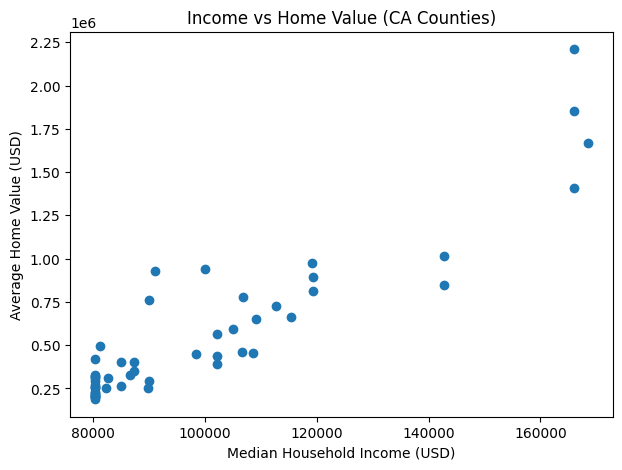

Correlation: 0.9152765929962461


In [18]:
## YOUR CODE HERE
import pandas as pd
import matplotlib.pyplot as plt

income = pd.read_csv("data/02-processed/income_limits_ca_2022.csv")
zillow = pd.read_csv("data/00-raw/Zip_Zhvi_SingleFamilyResidence_2018.csv")

print("Income shape:", income.shape)
print("Zillow shape:", zillow.shape)

zillow_ca = zillow[zillow["State"] == "CA"]

price_col = zillow_ca.columns[-1]

zillow_ca = zillow_ca[["CountyName", price_col]]
zillow_ca = zillow_ca.rename(columns={
    "CountyName": "county",
    price_col: "home_value"
})

zillow_county = zillow_ca.groupby("county")["home_value"].mean().reset_index()
zillow_county["county"] = zillow_county["county"].str.replace(" County", "", regex=False)

merged = pd.merge(income, zillow_county, on="county", how="inner")

plt.figure(figsize=(7,5))
plt.scatter(merged["median_household_income"], merged["home_value"])
plt.xlabel("Median Household Income (USD)")
plt.ylabel("Average Home Value (USD)")
plt.title("Income vs Home Value (CA Counties)")
plt.show()

corr = merged["median_household_income"].corr(merged["home_value"])
print("Correlation:", corr)

## Ethics

We use only aggregated, publicly available data (Zillow, Census/ACS-style income estimates, and CA Open Data for income limits). There are no individual-level records or identifying information. We considered potential sources of bias, including that Zillow data may better cover active, higher-priced markets and that survey-based income estimates contain sampling error.

To address these concerns, we are explicit about the data sources and their limitations, avoid making individual-level claims, and frame our results as descriptive patterns about regions and counties rather than about specific people. We store data locally in the course repository and do not deploy any model as a public-facing product. Our discussion of affordability emphasizes structural trends (e.g., supply, demand, regional inequality) rather than blaming particular groups of residents.

## Team Expectations 

All team members have read the [COGS108 Team Policies](https://github.com/COGS108/Projects/blob/master/COGS108_TeamPolicies.md) and agree to the following expectations.

- **Communication**: Communicate regularly through a shared platform (e.g., Discord or Slack) and attend scheduled meetings when possible.
- **Contribution**: Each member is expected to contribute equitably to data collection, analysis, and writing. If someone is overloaded, we will rebalance tasks.
- **Quality and deadlines**: We aim to have internal deadlines a few days before official due dates so there is time for review and revision.
- **Conflict resolution**: If conflicts arise, we agree to address them respectfully and promptly through group discussion. If needed, we will escalate to the instructor/IA following course policy.
- **Academic integrity**: We follow UCSD and COGS 108 academic integrity policies, ensuring that all code and writing we submit is our own work or properly cited.

By submitting this checkpoint, each member affirms that they intend to meet these expectations.

## Project Timeline Proposal

We organize our project timeline around data preparation, exploratory analysis, modeling (if needed), and writing. The plan below reflects updates since the proposal and data checkpoints.

| Week | Milestones | Details |
|------|-----------|---------|
| 3–4  | Finalize research question and identify datasets | Confirm access to Zillow ZHVI and CA income data; decide on UC-adjacent regions and counties. |
| 5    | Data cleaning and preprocessing | Download raw data, clean California ZHVI to `zhvi_sfr_zip_ca_2018.csv`, clean income limits to `income_limits_ca_2022.csv`, and verify join keys. |
| 6    | Data checkpoint and basic summaries | Submit Data Checkpoint; produce initial summaries and sanity checks for both datasets. |
| 7    | Exploratory data analysis (EDA) | Build county-level merged datasets, compute price-to-income ratios, create plots and correlation analyses (as in this EDA checkpoint). |
| 8    | Deeper analysis and robustness checks | Refine definition of UC-adjacent areas, explore time trends where possible, and test sensitivity to different aggregation choices. |
| 9    | Draft full report | Integrate figures, tables, and interpretation; expand ethics and limitations sections. |
| 10   | Final revisions and submission | Polish writing and visualizations, finalize conclusions, and submit final project and group surveys. |

**Update for EDA Checkpoint:** At this point we have cleaned the key datasets, constructed an initial county-level merged dataset, and completed first-round EDA on affordability and income–price relationships. Next steps are to refine geographic definitions (e.g., specific UC commuter zones), explore additional time slices where available, and finalize figures for the report.